In [1]:
# ============================================================
# CÉLULA 1 — Setup: importa o pipeline e prepara os dados
# ============================================================
import sys
from pathlib import Path

# Adiciona src/ ao path para importar nossos módulos
ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT / 'src' / 'preprocessing'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importa as funções do nosso pipeline.py
from pipeline import (
    carregar_dados, criar_preprocessador,
    separar_treino_teste, RANDOM_STATE,
    FEATURES_NUM, FEATURES_CAT
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

# Carrega e separa
X, y = carregar_dados()
X_train, X_test, y_train, y_test = separar_treino_teste(X, y)

print(f'Features numéricas:  {FEATURES_NUM}')
print(f'Features categóricas: {FEATURES_CAT}')
print(f'\nTreino: {X_train.shape[0]:,} municípios')
print(f'Teste:  {X_test.shape[0]:,} municípios')
print(f'\nProporção do alvo (treino): {y_train.mean():.1%} atingiram a meta')
print(f'Proporção do alvo (teste):  {y_test.mean():.1%} atingiram a meta')
print(f'\nrandom_state = {RANDOM_STATE} (replicabilidade garantida)')

Features numéricas:  ['taxa_2023', 'taxa_2024', 'variacao_2023_2024', 'melhorou', 'populacao', 'pib_per_capita']
Features categóricas: ['uf']

Treino: 4,273 municípios
Teste:  1,069 municípios

Proporção do alvo (treino): 72.8% atingiram a meta
Proporção do alvo (teste):  72.8% atingiram a meta

random_state = 42 (replicabilidade garantida)


In [2]:
# ============================================================
# CÉLULA 2 — Baseline e modelos candidatos
# ============================================================
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Estratégia de validação cruzada: 5 folds estratificados
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ── BASELINE ─────────────────────────────────────────────────
# "Chutar sempre a classe majoritária" — o mínimo a superar.
# Como 72,8% atingem a meta, um modelo burro que sempre diz
# "atingiu" já acerta 72,8%. Nosso modelo precisa BATER isso.
baseline = Pipeline([
    ('prep', criar_preprocessador()),
    ('clf', DummyClassifier(strategy='most_frequent'))
])

# ── MODELOS CANDIDATOS ───────────────────────────────────────
modelos = {
    'Regressão Logística': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',   # compensa o desbalanceamento 73/27
        random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE
    )
}

# Baseline primeiro
score_base = cross_val_score(
    baseline, X_train, y_train, cv=cv, scoring='accuracy'
).mean()
print(f'BASELINE (classe majoritária): {score_base:.3f} accuracy')
print('='*55)
print('Todo modelo abaixo precisa SUPERAR o baseline para ter valor.\n')

# Cada modelo dentro de um Pipeline (prep + modelo)
pipelines = {}
for nome, modelo in modelos.items():
    pipelines[nome] = Pipeline([
        ('prep', criar_preprocessador()),
        ('clf', modelo)
    ])
    print(f'✅ Pipeline criado: {nome}')

BASELINE (classe majoritária): 0.728 accuracy
Todo modelo abaixo precisa SUPERAR o baseline para ter valor.

✅ Pipeline criado: Regressão Logística
✅ Pipeline criado: Random Forest
✅ Pipeline criado: Gradient Boosting


In [3]:
# ============================================================
# CÉLULA 3 — Validação cruzada dos modelos candidatos
# ============================================================

# Avaliamos cada modelo com 4 métricas, via 5-fold CV.
# Usar várias métricas é essencial: com classes desbalanceadas,
# accuracy sozinha engana. Recall e F1 mostram se o modelo
# consegue identificar a classe minoritária (quem NÃO atinge).
metricas = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

resultados = []
for nome, pipe in pipelines.items():
    print(f'Avaliando {nome}...')
    linha = {'modelo': nome}
    for m in metricas:
        scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=m)
        linha[m] = scores.mean()
        linha[f'{m}_std'] = scores.std()
    resultados.append(linha)

# Monta tabela comparativa
df_result = pd.DataFrame(resultados).set_index('modelo')

print('\n' + '='*70)
print('COMPARAÇÃO DOS MODELOS (média da validação cruzada 5-fold)')
print('='*70)
cols_media = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
print(df_result[cols_media].round(3).to_string())

print(f'\nBaseline (accuracy): {score_base:.3f}')
print('\nDesvio-padrão da accuracy (estabilidade entre folds):')
for nome in df_result.index:
    print(f'  {nome}: ±{df_result.loc[nome, "accuracy_std"]:.3f}')

Avaliando Regressão Logística...
Avaliando Random Forest...
Avaliando Gradient Boosting...

COMPARAÇÃO DOS MODELOS (média da validação cruzada 5-fold)
                     accuracy  precision  recall     f1  roc_auc
modelo                                                          
Regressão Logística     0.731      0.876   0.735  0.799    0.803
Random Forest           0.768      0.851   0.826  0.838    0.798
Gradient Boosting       0.784      0.811   0.917  0.861    0.808

Baseline (accuracy): 0.728

Desvio-padrão da accuracy (estabilidade entre folds):
  Regressão Logística: ±0.013
  Random Forest: ±0.011
  Gradient Boosting: ±0.010


Modelo campeão (Gradient Boosting) treinado.


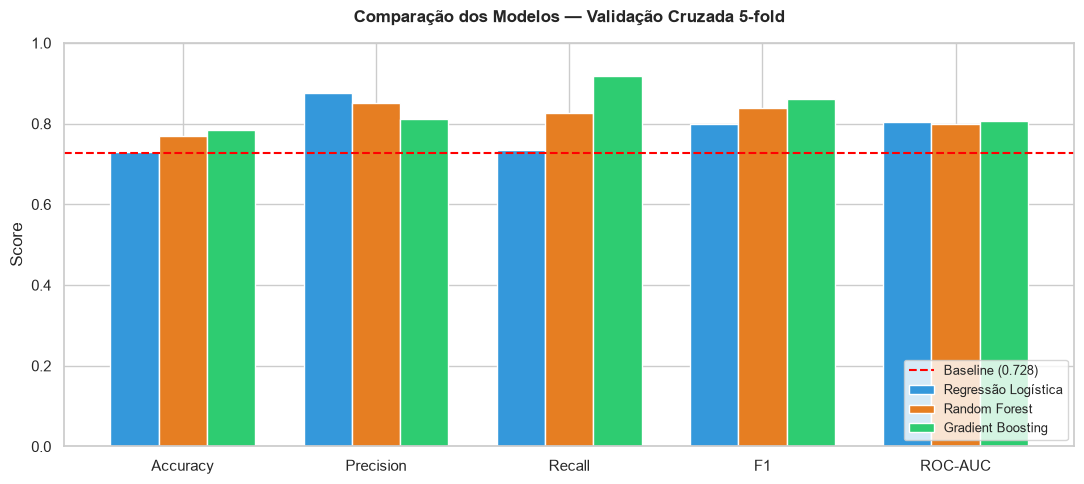

Figura salva em reports/figures/


In [4]:
# ============================================================
# CÉLULA 4 — Seleciona e treina o modelo campeão
# ============================================================

# Gradient Boosting: melhor F1 (0.861), melhor ROC-AUC (0.808),
# mais estável (menor desvio). É o modelo campeão.
modelo_campeao = pipelines['Gradient Boosting']

# Treina no conjunto de treino COMPLETO (os 4.273)
modelo_campeao.fit(X_train, y_train)
print('Modelo campeão (Gradient Boosting) treinado.')

# Gráfico comparativo dos modelos
fig, ax = plt.subplots(figsize=(11, 5))
metricas_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
x = np.arange(len(metricas_plot))
largura = 0.25
cores = ['#3498db', '#e67e22', '#2ecc71']

for i, nome in enumerate(df_result.index):
    valores = df_result.loc[nome, metricas_plot].values.astype(float)
    ax.bar(x + i*largura, valores, largura, label=nome, color=cores[i])

ax.axhline(score_base, color='red', linestyle='--',
           linewidth=1.5, label=f'Baseline ({score_base:.3f})')
ax.set_xticks(x + largura)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'])
ax.set_ylabel('Score')
ax.set_title('Comparação dos Modelos — Validação Cruzada 5-fold',
             fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=9)
ax.set_ylim(0, 1.0)
plt.tight_layout()
fig.savefig(ROOT / 'reports' / 'figures' / '05_comparacao_modelos.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva em reports/figures/')

In [5]:
# ============================================================
# CÉLULA 5 — Tuning de hiperparâmetros (GridSearchCV)
# ============================================================
from sklearn.model_selection import GridSearchCV

# Grade de hiperparâmetros do Gradient Boosting.
# Testamos combinações para controlar overfitting e capacidade:
#   - n_estimators: nº de árvores
#   - learning_rate: quanto cada árvore corrige (menor = mais estável)
#   - max_depth: profundidade (menor = menos overfitting)
param_grid = {
    'clf__n_estimators': [100, 200, 300],
    'clf__learning_rate': [0.05, 0.1],
    'clf__max_depth': [2, 3, 4]
}

# Pipeline base do Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
pipe_gb = Pipeline([
    ('prep', criar_preprocessador()),
    ('clf', GradientBoostingClassifier(random_state=RANDOM_STATE))
])

# GridSearch otimizando F1 (nossa métrica de equilíbrio)
grid = GridSearchCV(
    pipe_gb,
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print('Iniciando busca (18 combinações x 5 folds = 90 treinos)...')
print('Pode levar 1-2 minutos.\n')
grid.fit(X_train, y_train)

print('\n' + '='*55)
print('MELHORES HIPERPARÂMETROS')
print('='*55)
for param, valor in grid.best_params_.items():
    print(f'  {param}: {valor}')
print(f'\nMelhor F1 (validação cruzada): {grid.best_score_:.3f}')
print(f'F1 do modelo sem tuning:       0.861')

# Guarda o melhor modelo
modelo_otimizado = grid.best_estimator_

Iniciando busca (18 combinações x 5 folds = 90 treinos)...
Pode levar 1-2 minutos.

Fitting 5 folds for each of 18 candidates, totalling 90 fits

MELHORES HIPERPARÂMETROS
  clf__learning_rate: 0.05
  clf__max_depth: 4
  clf__n_estimators: 100

Melhor F1 (validação cruzada): 0.865
F1 do modelo sem tuning:       0.861


In [6]:
# ============================================================
# CÉLULA 6 — Avaliação final no conjunto de teste
# ============================================================
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

# Previsões no teste (dados nunca vistos)
y_pred = modelo_otimizado.predict(X_test)
y_proba = modelo_otimizado.predict_proba(X_test)[:, 1]

print('='*55)
print('AVALIAÇÃO FINAL — CONJUNTO DE TESTE (1.069 municípios)')
print('='*55)
print(f'  Accuracy:  {accuracy_score(y_test, y_pred):.3f}')
print(f'  Precision: {precision_score(y_test, y_pred):.3f}')
print(f'  Recall:    {recall_score(y_test, y_pred):.3f}')
print(f'  F1-Score:  {f1_score(y_test, y_pred):.3f}')
print(f'  ROC-AUC:   {roc_auc_score(y_test, y_proba):.3f}')
print(f'\n  Baseline:  {score_base:.3f}')

print('\n' + '='*55)
print('RELATÓRIO POR CLASSE')
print('='*55)
print(classification_report(
    y_test, y_pred,
    target_names=['Não atingiu (0)', 'Atingiu (1)']
))

AVALIAÇÃO FINAL — CONJUNTO DE TESTE (1.069 municípios)
  Accuracy:  0.795
  Precision: 0.811
  Recall:    0.937
  F1-Score:  0.869
  ROC-AUC:   0.829

  Baseline:  0.728

RELATÓRIO POR CLASSE
                 precision    recall  f1-score   support

Não atingiu (0)       0.71      0.42      0.52       291
    Atingiu (1)       0.81      0.94      0.87       778

       accuracy                           0.80      1069
      macro avg       0.76      0.68      0.70      1069
   weighted avg       0.78      0.80      0.78      1069



In [7]:
# ============================================================
# CÉLULA 7 — Salva o modelo final e as métricas
# ============================================================
import joblib
import json

# Salva o modelo otimizado (pipeline completo: prep + modelo)
caminho_modelo = ROOT / 'models' / 'modelo_gradient_boosting.pkl'
joblib.dump(modelo_otimizado, caminho_modelo)
print(f'Modelo salvo em: {caminho_modelo}')

# Salva as métricas finais num JSON (para o README e rastreabilidade)
metricas_finais = {
    'modelo': 'Gradient Boosting (otimizado)',
    'hiperparametros': grid.best_params_,
    'baseline': round(float(score_base), 3),
    'teste': {
        'accuracy':  round(float(accuracy_score(y_test, y_pred)), 3),
        'precision': round(float(precision_score(y_test, y_pred)), 3),
        'recall':    round(float(recall_score(y_test, y_pred)), 3),
        'f1':        round(float(f1_score(y_test, y_pred)), 3),
        'roc_auc':   round(float(roc_auc_score(y_test, y_proba)), 3),
    },
    'recall_classe_0': round(float(
        recall_score(y_test, y_pred, pos_label=0)), 3),
    'observacao': 'Recall baixo na classe 0 (municipios em risco) '
                  'e o principal achado — features separam melhor '
                  'sucesso que fracasso.'
}

caminho_metricas = ROOT / 'reports' / 'metricas_finais.json'
with open(caminho_metricas, 'w', encoding='utf-8') as f:
    json.dump(metricas_finais, f, indent=2, ensure_ascii=False)
print(f'Métricas salvas em: {caminho_metricas}')

print('\nResumo salvo:')
print(json.dumps(metricas_finais, indent=2, ensure_ascii=False))

Modelo salvo em: C:\Users\domain\tech-challenge-fase3\models\modelo_gradient_boosting.pkl
Métricas salvas em: C:\Users\domain\tech-challenge-fase3\reports\metricas_finais.json

Resumo salvo:
{
  "modelo": "Gradient Boosting (otimizado)",
  "hiperparametros": {
    "clf__learning_rate": 0.05,
    "clf__max_depth": 4,
    "clf__n_estimators": 100
  },
  "baseline": 0.728,
  "teste": {
    "accuracy": 0.795,
    "precision": 0.811,
    "recall": 0.937,
    "f1": 0.869,
    "roc_auc": 0.829
  },
  "recall_classe_0": 0.416,
  "observacao": "Recall baixo na classe 0 (municipios em risco) e o principal achado — features separam melhor sucesso que fracasso."
}


FEATURE IMPORTANCE — Top 15
           feature  importancia
variacao_2023_2024     0.321542
             uf_RS     0.126918
         populacao     0.118803
         taxa_2024     0.116712
    pib_per_capita     0.054206
         taxa_2023     0.047390
             uf_BA     0.042976
          melhorou     0.037638
             uf_PR     0.034770
             uf_SC     0.023247
             uf_SP     0.011944
             uf_AC     0.007937
             uf_MT     0.007920
             uf_CE     0.007770
             uf_MG     0.007577

Soma das top 6 importâncias: 78.6%
Feature mais importante: variacao_2023_2024 (32.2%)


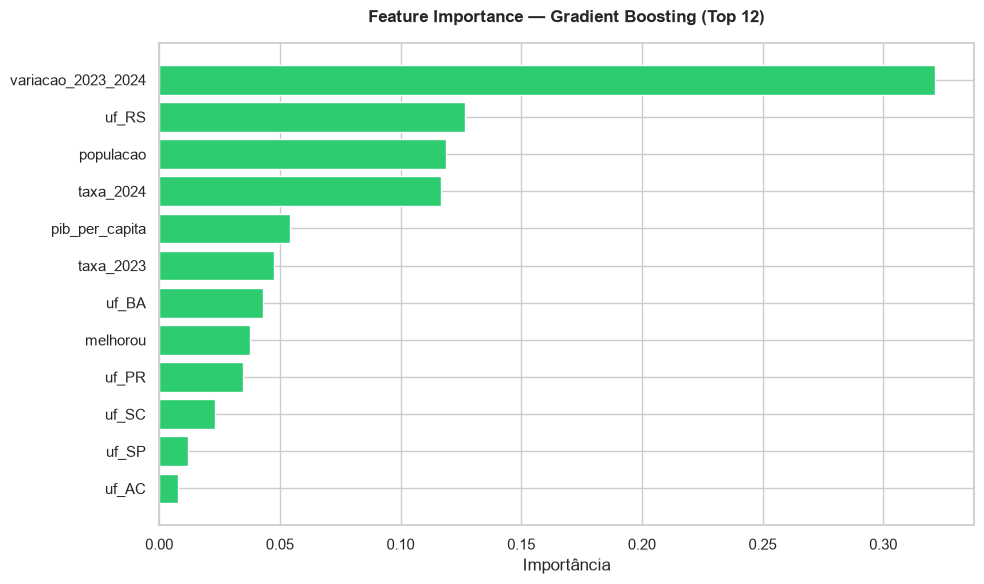

Figura salva em reports/figures/


In [8]:
# ============================================================
# CÉLULA 8 — Feature Importance do modelo campeão
# ============================================================

# O Gradient Boosting expõe feature_importances_, mas os nomes
# das features mudaram após o one-hot (uf virou 26 colunas).
# Precisamos recuperar os nomes reais do pré-processador.

# Extrai o pré-processador e o classificador já treinados
prep_treinado = modelo_otimizado.named_steps['prep']
clf_treinado  = modelo_otimizado.named_steps['clf']

# Recupera os nomes das features após transformação
nomes_features = prep_treinado.get_feature_names_out()
importancias = clf_treinado.feature_importances_

# Monta DataFrame ordenado
df_imp = pd.DataFrame({
    'feature': nomes_features,
    'importancia': importancias
}).sort_values('importancia', ascending=False)

# Limpa os prefixos (num__ e cat__) para leitura
df_imp['feature'] = df_imp['feature'].str.replace('num__', '', regex=False)
df_imp['feature'] = df_imp['feature'].str.replace('cat__', '', regex=False)

print('='*55)
print('FEATURE IMPORTANCE — Top 15')
print('='*55)
print(df_imp.head(15).to_string(index=False))

print(f'\nSoma das top 6 importâncias: {df_imp.head(6)["importancia"].sum():.1%}')
print(f'Feature mais importante: {df_imp.iloc[0]["feature"]} '
      f'({df_imp.iloc[0]["importancia"]:.1%})')

# Gráfico das top 12
fig, ax = plt.subplots(figsize=(10, 6))
top = df_imp.head(12).sort_values('importancia')
ax.barh(top['feature'], top['importancia'], color='#2ecc71', edgecolor='white')
ax.set_xlabel('Importância')
ax.set_title('Feature Importance — Gradient Boosting (Top 12)',
             fontweight='bold', pad=15)
plt.tight_layout()
fig.savefig(ROOT / 'reports' / 'figures' / '06_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva em reports/figures/')

Calculando SHAP values (pode levar ~30s)...
✅ SHAP values calculados.


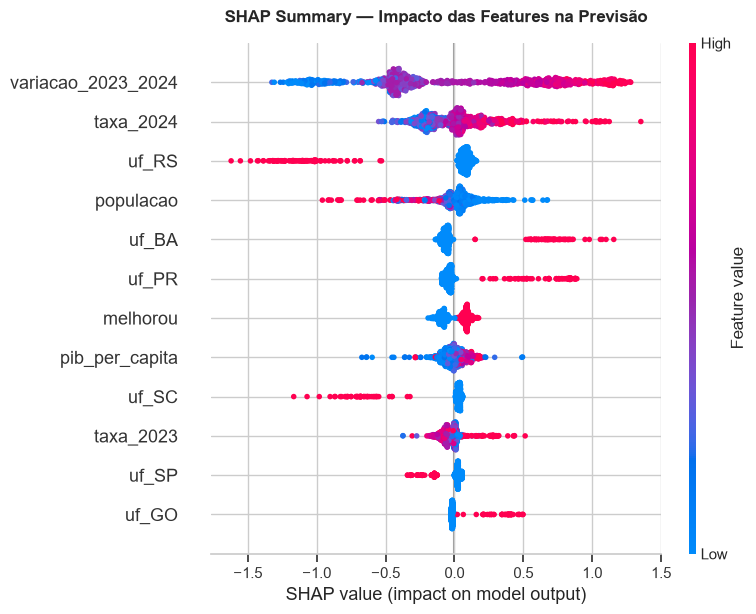

Figura salva em reports/figures/


In [9]:
# ============================================================
# CÉLULA 9 — SHAP Values (interpretabilidade avançada)
# ============================================================
import shap

# O SHAP precisa dos dados JÁ transformados pelo pré-processador,
# porque ele explica o classificador que recebe as 31 colunas.
# Transformamos o conjunto de teste com o prep já treinado.
X_test_transformado = prep_treinado.transform(X_test)
nomes = prep_treinado.get_feature_names_out()
nomes = [n.replace('num__', '').replace('cat__', '') for n in nomes]

X_test_df = pd.DataFrame(X_test_transformado, columns=nomes)

# TreeExplainer é otimizado para modelos de árvore (Gradient Boosting)
print('Calculando SHAP values (pode levar ~30s)...')
explainer = shap.TreeExplainer(clf_treinado)
shap_values = explainer.shap_values(X_test_df)
print('✅ SHAP values calculados.')

# Gráfico 1: summary plot (importância + direção de cada feature)
fig = plt.figure()
shap.summary_plot(
    shap_values, X_test_df,
    max_display=12, show=False
)
plt.title('SHAP Summary — Impacto das Features na Previsão',
          fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'figures' / '07_shap_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva em reports/figures/')

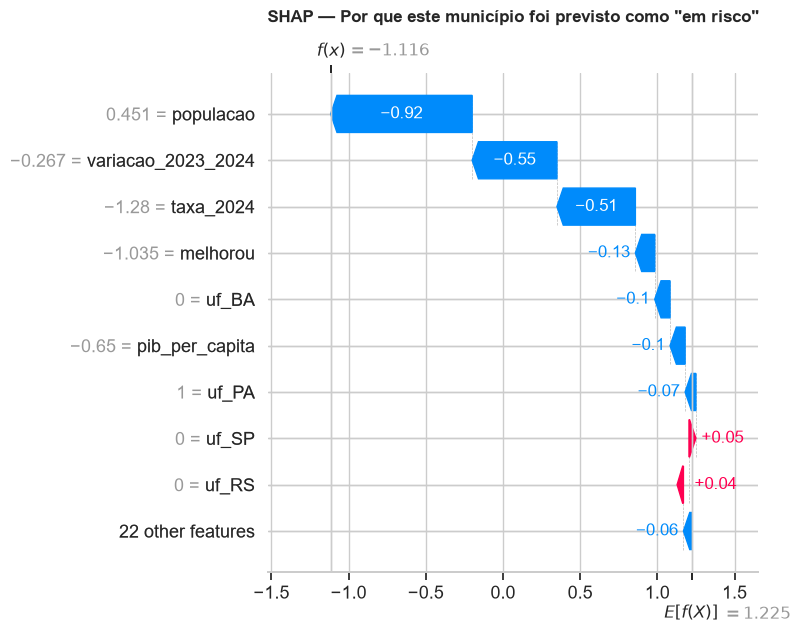

Figura salva em reports/figures/

Município explicado (índice 6):
  Real: NÃO atingiu
  Previsto: NÃO atingiu


In [10]:
# ============================================================
# CÉLULA 10 — SHAP para casos individuais (waterfall)
# ============================================================

# Escolhe dois municípios de teste para explicar:
# um que atingiu e um que não atingiu, ambos previstos corretamente.
y_test_reset = y_test.reset_index(drop=True)
y_pred_series = pd.Series(y_pred)

# Índice de um município que NÃO atingiu e o modelo acertou
idx_risco = y_test_reset[(y_test_reset == 0) & (y_pred_series == 0)].index[0]

# Explicação individual (waterfall)
explanation = shap.Explanation(
    values=shap_values[idx_risco],base_values=float(np.array(explainer.expected_value).flatten()[0]),
    data=X_test_df.iloc[idx_risco].values,
    feature_names=list(X_test_df.columns)
)

fig = plt.figure()
shap.plots.waterfall(explanation, max_display=10, show=False)
plt.title('SHAP — Por que este município foi previsto como "em risco"',
          fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'figures' / '08_shap_waterfall.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva em reports/figures/')
print(f'\nMunicípio explicado (índice {idx_risco}):')
print(f'  Real: {"Atingiu" if y_test_reset[idx_risco]==1 else "NÃO atingiu"}')
print(f'  Previsto: {"Atingiu" if y_pred_series[idx_risco]==1 else "NÃO atingiu"}')

In [11]:
# ============================================================
# CÉLULA 11 — Ranking de municípios em maior risco
# ============================================================

# Aplica o modelo a TODA a base para gerar probabilidades.
df_completo = pd.read_parquet(
    ROOT / 'data' / 'processed' / 'base_modelagem.parquet'
)

# Features na mesma ordem do treino
X_completo = df_completo[FEATURES_NUM + FEATURES_CAT].copy()

# Probabilidade de ATINGIR a meta (classe 1)
prob_atingir = modelo_otimizado.predict_proba(X_completo)[:, 1]

# Risco = probabilidade de NÃO atingir (1 - prob de atingir)
df_completo['prob_atingir'] = prob_atingir.round(3)
df_completo['risco'] = (1 - prob_atingir).round(3)
df_completo['previsao'] = modelo_otimizado.predict(X_completo)

# Ranking dos 20 municípios em MAIOR risco
ranking_risco = df_completo.sort_values('risco', ascending=False).head(20)

print('='*70)
print('TOP 20 MUNICÍPIOS EM MAIOR RISCO DE NÃO ATINGIR A META')
print('='*70)
print(ranking_risco[[
    'id_municipio', 'uf', 'taxa_2024',
    'variacao_2023_2024', 'risco'
]].to_string(index=False))

# Distribuição do risco por UF
print('\n' + '='*55)
print('RISCO MÉDIO POR ESTADO (top 10 mais críticos)')
print('='*55)
risco_uf = df_completo.groupby('uf').agg(
    municipios=('id_municipio', 'count'),
    risco_medio=('risco', 'mean'),
    previstos_em_risco=('previsao', lambda x: (x == 0).sum())
).round(3)
risco_uf['perc_em_risco'] = (
    risco_uf['previstos_em_risco'] / risco_uf['municipios'] * 100
).round(1)
risco_uf = risco_uf.sort_values('risco_medio', ascending=False)
print(risco_uf.head(10).to_string())

TOP 20 MUNICÍPIOS EM MAIOR RISCO DE NÃO ATINGIR A META
 id_municipio uf  taxa_2024  variacao_2023_2024  risco
      4316808 RS       48.4              -21.39  0.930
      4316907 RS       40.3              -24.54  0.926
      4305108 RS       43.6              -23.87  0.923
      4303103 RS       40.5              -19.06  0.923
      4313409 RS       37.0              -25.48  0.921
      4309209 RS       40.5              -22.49  0.921
      4314100 RS       36.5              -22.18  0.919
      4318705 RS       37.5              -18.93  0.919
      4322400 RS       45.7              -15.24  0.914
      4301602 RS       43.3              -16.30  0.914
      4304705 RS       46.5              -22.80  0.913
      4322509 RS       41.3              -29.47  0.913
      4319901 RS       43.8              -26.02  0.913
      4317202 RS       51.2              -18.93  0.913
      4321204 RS       45.0              -16.27  0.912
      4318309 RS       39.1              -23.64  0.912
      4307

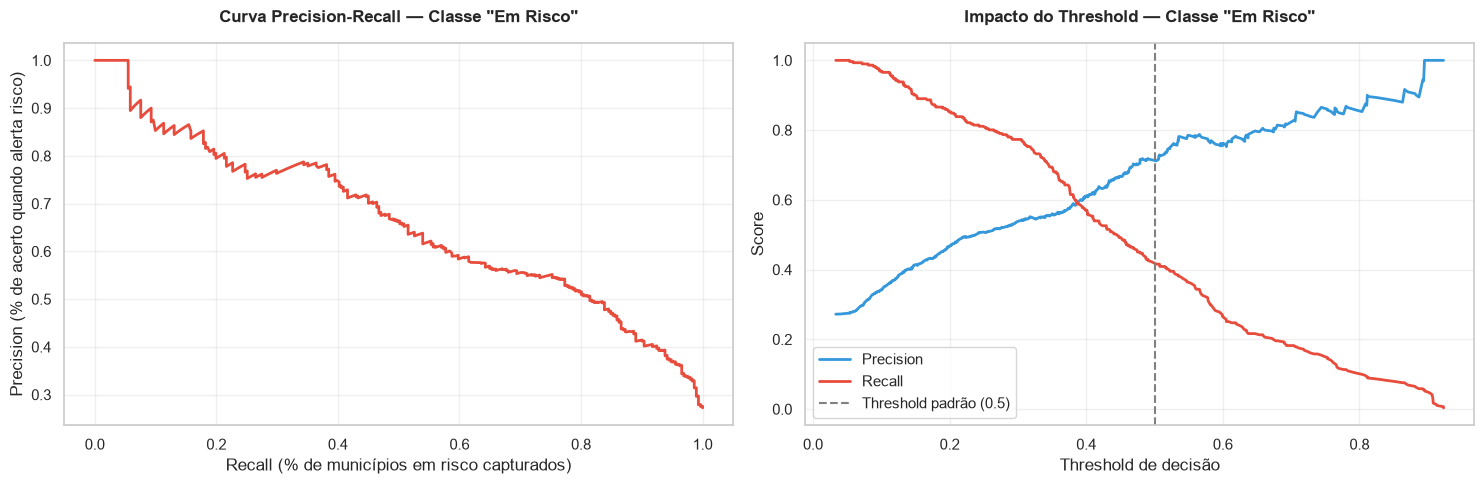

RECALL DA CLASSE "EM RISCO" EM DIFERENTES THRESHOLDS
  Threshold 0.30 → Recall: 77.3% | Precision: 53.8%
  Threshold 0.40 → Recall: 57.0% | Precision: 61.3%
  Threshold 0.50 → Recall: 41.6% | Precision: 71.2%
  Threshold 0.60 → Recall: 26.5% | Precision: 76.2%


In [12]:
# ============================================================
# CÉLULA 12 — Trade-off de threshold (curva precision-recall)
# ============================================================
from sklearn.metrics import precision_recall_curve, precision_score, recall_score

# Foco na classe 0 (municípios EM RISCO) — a que importa
# para política pública. Invertemos: y=1 quando NÃO atingiu.
y_test_risco = (y_test == 0).astype(int)
prob_risco_test = 1 - modelo_otimizado.predict_proba(X_test)[:, 1]

# Curva precision-recall para a classe de risco
prec, rec, thresholds = precision_recall_curve(y_test_risco, prob_risco_test)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: curva precision-recall
axes[0].plot(rec, prec, color='#e74c3c', linewidth=2)
axes[0].set_xlabel('Recall (% de municípios em risco capturados)')
axes[0].set_ylabel('Precision (% de acerto quando alerta risco)')
axes[0].set_title('Curva Precision-Recall — Classe "Em Risco"',
                  fontweight='bold', pad=15)
axes[0].grid(True, alpha=0.3)

# Gráfico 2: como recall e precision variam com o threshold
axes[1].plot(thresholds, prec[:-1], label='Precision',
             color='#3498db', linewidth=2)
axes[1].plot(thresholds, rec[:-1], label='Recall',
             color='#e74c3c', linewidth=2)
axes[1].axvline(0.5, color='gray', linestyle='--',
                label='Threshold padrão (0.5)')
axes[1].set_xlabel('Threshold de decisão')
axes[1].set_ylabel('Score')
axes[1].set_title('Impacto do Threshold — Classe "Em Risco"',
                  fontweight='bold', pad=15)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(ROOT / 'reports' / 'figures' / '09_threshold_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Compara recall em diferentes thresholds
print('='*60)
print('RECALL DA CLASSE "EM RISCO" EM DIFERENTES THRESHOLDS')
print('='*60)
for t in [0.30, 0.40, 0.50, 0.60]:
    pred_t = (prob_risco_test >= t).astype(int)
    p = precision_score(y_test_risco, pred_t, zero_division=0)
    r = recall_score(y_test_risco, pred_t, zero_division=0)
    print(f'  Threshold {t:.2f} → Recall: {r:.1%} | Precision: {p:.1%}')

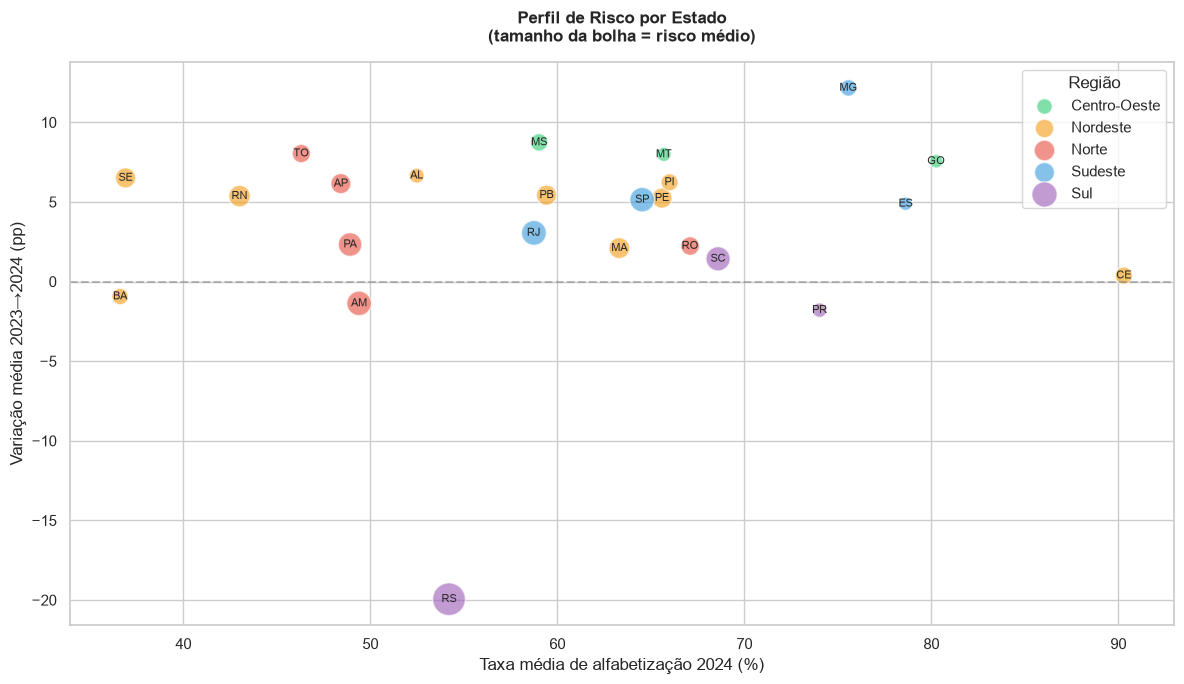

ESTADOS ORDENADOS POR RISCO MÉDIO:
          regiao  risco_medio  taxa_media_2024  variacao_media
uf                                                            
RS           Sul        0.694           54.202         -19.950
RJ       Sudeste        0.398           58.743           3.057
SP       Sudeste        0.390           64.530           5.144
AM         Norte        0.388           49.393          -1.369
SC           Sul        0.379           68.591           1.430
PA         Norte        0.359           48.912           2.328
RN      Nordeste        0.300           43.002           5.366
MA      Nordeste        0.280           63.309           2.101
PE      Nordeste        0.263           65.588           5.242
SE      Nordeste        0.262           36.905           6.512
PB      Nordeste        0.261           59.417           5.426
AP         Norte        0.260           48.419           6.152
RO         Norte        0.223           67.099           2.233
TO         Norte    

In [13]:
# ============================================================
# CÉLULA 13 — Agrupamento de estados por perfil de risco
# ============================================================

# Perfil de cada UF: risco médio, taxa média, variação média
perfil_uf = df_completo.groupby('uf').agg(
    risco_medio=('risco', 'mean'),
    taxa_media_2024=('taxa_2024', 'mean'),
    variacao_media=('variacao_2023_2024', 'mean'),
    municipios=('id_municipio', 'count')
).round(3)

# Adiciona a região
REGIOES = {
    'AC':'Norte','AM':'Norte','AP':'Norte','PA':'Norte','RO':'Norte',
    'RR':'Norte','TO':'Norte','AL':'Nordeste','BA':'Nordeste',
    'CE':'Nordeste','MA':'Nordeste','PB':'Nordeste','PE':'Nordeste',
    'PI':'Nordeste','RN':'Nordeste','SE':'Nordeste','DF':'Centro-Oeste',
    'GO':'Centro-Oeste','MS':'Centro-Oeste','MT':'Centro-Oeste',
    'ES':'Sudeste','MG':'Sudeste','RJ':'Sudeste','SP':'Sudeste',
    'PR':'Sul','RS':'Sul','SC':'Sul'
}
perfil_uf['regiao'] = perfil_uf.index.map(REGIOES)

# Scatter: taxa vs variação, tamanho = risco
fig, ax = plt.subplots(figsize=(12, 7))
cores_reg = {'Norte':'#e74c3c','Nordeste':'#f39c12',
             'Centro-Oeste':'#2ecc71','Sudeste':'#3498db','Sul':'#9b59b6'}

for regiao, grupo in perfil_uf.groupby('regiao'):
    ax.scatter(grupo['taxa_media_2024'], grupo['variacao_media'],
               s=grupo['risco_medio']*800, alpha=0.6,
               color=cores_reg[regiao], label=regiao, edgecolors='white')
    for uf, row in grupo.iterrows():
        ax.annotate(uf, (row['taxa_media_2024'], row['variacao_media']),
                    fontsize=8, ha='center', va='center')

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Taxa média de alfabetização 2024 (%)')
ax.set_ylabel('Variação média 2023→2024 (pp)')
ax.set_title('Perfil de Risco por Estado\n(tamanho da bolha = risco médio)',
             fontweight='bold', pad=15)
ax.legend(title='Região')
plt.tight_layout()
fig.savefig(ROOT / 'reports' / 'figures' / '10_perfil_regional.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('ESTADOS ORDENADOS POR RISCO MÉDIO:')
print(perfil_uf.sort_values('risco_medio', ascending=False)[
    ['regiao','risco_medio','taxa_media_2024','variacao_media']
].to_string())

In [14]:
# ============================================================
# CÉLULA 14 — Síntese: respostas às perguntas de negócio
# ============================================================

sintese = """
╔══════════════════════════════════════════════════════════════╗
║   APLICAÇÃO ESTRATÉGICA — Respostas às Perguntas de Negócio   ║
╚══════════════════════════════════════════════════════════════╝

1. QUAIS FATORES MAIS IMPACTAM A ALFABETIZAÇÃO?
   → A TRAJETÓRIA (variação 2023→2024) é o fator dominante
     (32% da importância). Municípios em queda têm alto risco.
   → O ESTADO importa muito: pertencer ao RS é forte preditor
     de risco; BA e PR puxam para o sucesso.
   → Taxa histórica de 2024 e porte populacional completam o topo.

2. QUAIS MUNICÍPIOS TÊM MAIOR RISCO EDUCACIONAL?
   → Os 20 de maior risco são TODOS do Rio Grande do Sul,
     todos com queda acentuada entre 2023 e 2024 (-15 a -29 pp).
   → RS tem 86,5% dos municípios em risco — disparado o pior.

3. QUAIS REGIÕES TÊM PADRÕES SEMELHANTES?
   → Sul (RS) e Sudeste (RJ, SP) concentram o maior risco —
     estados com metas ambiciosas.
   → Nordeste melhora de um patamar baixo; Centro-Oeste tem o
     perfil ideal (taxa alta + em melhora).

4. COMO PREVER MUNICÍPIOS QUE PODEM NÃO ATINGIR METAS?
   → O modelo Gradient Boosting gera probabilidade de risco
     por município (ROC-AUC 0,83 no teste).
   → Ajustando o threshold de 0,50 para 0,30, a captura de
     municípios em risco sobe de 42% para 77% — decisão que
     cabe ao gestor conforme o orçamento de intervenção.

5. QUAIS VARIÁVEIS MAIS INFLUENCIAM O MODELO?
   → SHAP confirma: variação 2023→2024, taxa 2024, estado (RS),
     e população. Sinal distribuído — modelo íntegro, sem leakage.

──────────────────────────────────────────────────────────────
RECOMENDAÇÃO DE POLÍTICA PÚBLICA:
Priorizar intervenção em municípios com TRAJETÓRIA DE QUEDA,
com atenção especial ao Rio Grande do Sul. Usar o modelo como
ferramenta de TRIAGEM (threshold baixo) para não deixar
municípios em risco passarem despercebidos.
──────────────────────────────────────────────────────────────
"""
print(sintese)


╔══════════════════════════════════════════════════════════════╗
║   APLICAÇÃO ESTRATÉGICA — Respostas às Perguntas de Negócio   ║
╚══════════════════════════════════════════════════════════════╝

1. QUAIS FATORES MAIS IMPACTAM A ALFABETIZAÇÃO?
   → A TRAJETÓRIA (variação 2023→2024) é o fator dominante
     (32% da importância). Municípios em queda têm alto risco.
   → O ESTADO importa muito: pertencer ao RS é forte preditor
     de risco; BA e PR puxam para o sucesso.
   → Taxa histórica de 2024 e porte populacional completam o topo.

2. QUAIS MUNICÍPIOS TÊM MAIOR RISCO EDUCACIONAL?
   → Os 20 de maior risco são TODOS do Rio Grande do Sul,
     todos com queda acentuada entre 2023 e 2024 (-15 a -29 pp).
   → RS tem 86,5% dos municípios em risco — disparado o pior.

3. QUAIS REGIÕES TÊM PADRÕES SEMELHANTES?
   → Sul (RS) e Sudeste (RJ, SP) concentram o maior risco —
     estados com metas ambiciosas.
   → Nordeste melhora de um patamar baixo; Centro-Oeste tem o
     perfil ideal (taxa